<br><h1>Fake News Detection Part 1</h1><br>

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
import re
import sys

pd.set_option('display.max_columns', 200)
plt.style.use("ggplot")

In [3]:
# Read data
_filepath = "./data/news_sample.csv"
df = pl.read_csv(_filepath).drop([""])  # drop the unnamed first column
df

id,domain,type,url,content,scraped_at,inserted_at,updated_at,title,authors,keywords,meta_keywords,meta_description,tags,summary
i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str
141,"""awm.com""","""unreliable""","""http://awm.com/church-congrega…","""Sometimes the power of Christm…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Church Congregation Brings Gif…","""Ruth Harris""",null,"""['']""",null,null,null
256,"""beforeitsnews.com""","""fake""","""http://beforeitsnews.com/awake…","""AWAKENING OF 12 STRANDS of DNA…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""AWAKENING OF 12 STRANDS of DNA…","""Zurich Times""",null,"""['']""",null,null,null
700,"""cnnnext.com""","""unreliable""","""http://www.cnnnext.com/video/1…","""Never Hike Alone: A Friday the…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Never Hike Alone - A Friday th…",null,null,"""['']""","""Never Hike Alone: A Friday the…",null,null
768,"""awm.com""","""unreliable""","""http://awm.com/elusive-alien-o…","""When a rare shark was caught, …","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Elusive ‘Alien Of The Sea ‘ Ca…","""Alexander Smith""",null,"""['']""",null,null,null
791,"""bipartisanreport.com""","""clickbait""","""http://bipartisanreport.com/20…","""Donald Trump has the unnerving…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Trump’s Genius Poll Is Complet…","""Gloria Christie""",null,"""['']""",null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
39259,"""beforeitsnews.com""","""fake""","""http://beforeitsnews.com/econo…","""Prison for Rahm, God’s Work An…","""2018-01-25 20:13:50.426130""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Prison for Rahm, God’s Work An…",null,null,"""['']""",null,null,null
39468,"""beforeitsnews.com""","""fake""","""http://beforeitsnews.com/diy/2…","""4 Useful Items for Your Tiny H…","""2018-01-25 20:13:50.426130""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""4 Useful Items for Your Tiny H…","""Dimitry K""",null,"""['']""",null,null,null
39477,"""www.newsmax.com""",null,"""https://www.newsmax.com/politi…","""Former CIA Director Michael Ha…","""2018-01-25 20:13:50.426130""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Michael Hayden: We Should Be '…","""Todd Beamon""",null,"""['michael hayden', 'sthole cou…","""President Donald Trump's repor…","""Homeland Security, Trump Admin…",null


In [4]:
df_1 = (
    df.drop(["keywords", "summary"])
    .fill_null("nan")
    .with_columns(
        pl.when(pl.col("meta_keywords") == "['']")
        .then(pl.lit("nan"))
        .otherwise(pl.col("meta_keywords"))
        .alias("meta_keywords")
    )
)
df_1

id,domain,type,url,content,scraped_at,inserted_at,updated_at,title,authors,meta_keywords,meta_description,tags
i64,str,str,str,str,str,str,str,str,str,str,str,str
141,"""awm.com""","""unreliable""","""http://awm.com/church-congrega…","""Sometimes the power of Christm…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Church Congregation Brings Gif…","""Ruth Harris""","""nan""","""nan""","""nan"""
256,"""beforeitsnews.com""","""fake""","""http://beforeitsnews.com/awake…","""AWAKENING OF 12 STRANDS of DNA…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""AWAKENING OF 12 STRANDS of DNA…","""Zurich Times""","""nan""","""nan""","""nan"""
700,"""cnnnext.com""","""unreliable""","""http://www.cnnnext.com/video/1…","""Never Hike Alone: A Friday the…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Never Hike Alone - A Friday th…","""nan""","""nan""","""Never Hike Alone: A Friday the…","""nan"""
768,"""awm.com""","""unreliable""","""http://awm.com/elusive-alien-o…","""When a rare shark was caught, …","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Elusive ‘Alien Of The Sea ‘ Ca…","""Alexander Smith""","""nan""","""nan""","""nan"""
791,"""bipartisanreport.com""","""clickbait""","""http://bipartisanreport.com/20…","""Donald Trump has the unnerving…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Trump’s Genius Poll Is Complet…","""Gloria Christie""","""nan""","""nan""","""nan"""
…,…,…,…,…,…,…,…,…,…,…,…,…
39259,"""beforeitsnews.com""","""fake""","""http://beforeitsnews.com/econo…","""Prison for Rahm, God’s Work An…","""2018-01-25 20:13:50.426130""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Prison for Rahm, God’s Work An…","""nan""","""nan""","""nan""","""nan"""
39468,"""beforeitsnews.com""","""fake""","""http://beforeitsnews.com/diy/2…","""4 Useful Items for Your Tiny H…","""2018-01-25 20:13:50.426130""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""4 Useful Items for Your Tiny H…","""Dimitry K""","""nan""","""nan""","""nan"""
39477,"""www.newsmax.com""","""nan""","""https://www.newsmax.com/politi…","""Former CIA Director Michael Ha…","""2018-01-25 20:13:50.426130""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Michael Hayden: We Should Be '…","""Todd Beamon""","""['michael hayden', 'sthole cou…","""President Donald Trump's repor…","""Homeland Security, Trump Admin…"


In [5]:
df_1.describe()

statistic,id,domain,type,url,content,scraped_at,inserted_at,updated_at,title,authors,meta_keywords,meta_description,tags
str,f64,str,str,str,str,str,str,str,str,str,str,str,str
"""count""",250.0,"""250""","""250""","""250""","""250""","""250""","""250""","""250""","""250""","""250""","""250""","""250""","""250"""
"""null_count""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0"""
"""mean""",20241.56,null,null,null,null,null,null,null,null,null,null,null,null
"""std""",11515.412728,null,null,null,null,null,null,null,null,null,null,null,null
"""min""",141.0,"""21stcenturywire.com""","""bias""","""http://21stcenturywire.com/201…","""(NaturalNews) If you thought B…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""'Stop Christie' PAC quits, say…","""A Bad Witch'S Blog""","""['', 'Big Government', 'mark l…","""'Enough meddling ... Go home, …","""Achievement Gap, GOP Share Of …"
"""25%""",11001.0,null,null,null,null,null,null,null,null,null,null,null,null
"""50%""",21093.0,null,null,null,null,null,null,null,null,null,null,null,null
"""75%""",29104.0,null,null,null,null,null,null,null,null,null,null,null,null
"""max""",39558.0,"""www.newsmax.com""","""unreliable""","""https://www.undergroundhealth.…","""“Voice or no voice, the people…","""2018-01-25 20:13:50.426130""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""“Draining the Swamp” Doesn’t M…","""nan""","""nan""","""“We are on the precipice of co…","""out of iraq, end the occupatio…"


In [6]:
# Uncompiled patterns for polars later
email_str = r'[^ \n,"]+@[^ \n,"]+\.[^ \n,"]+'
date_str = r'[0-9]{2,4}[-/][0-9]{2,4}[-/][0-9]{2,4}'
url_str = r'(?:http)?s?(?://)?[^ \n,"]+\.[a-z]{2,}[^ \n,"]+'
num_str = r'[0-9]+[,.]?[0-9]*'
special_str = r'[^a-zA-Z\-<>\'’‘ʼ′＇]'
apostrephe_str = r'\'’‘ʼ′＇'
ws_str = r'\s+'

# Pattern strings — shared with Task 2 (Polars uses these directly)
email_re = re.compile(email_str)
date_re = re.compile(date_str)
url_re = re.compile(url_str)
num_re = re.compile(num_str)
special_re = re.compile(special_str)
apostrephe_re = re.compile(apostrephe_str)
ws_re = re.compile(ws_str)

def clean_text(doc: str):
    lower_case = doc.lower()
    substituted = email_re.sub(" <EMAIL> ", lower_case)
    substituted = date_re.sub(" <DATE> ", substituted)
    substituted = url_re.sub(" <URL> ", substituted)
    substituted = num_re.sub(" <NUM> ", substituted)
    no_specials = special_re.sub(" ", substituted)
    no_apostrophes = apostrephe_re.sub("", no_specials)
    cleaned = ws_re.sub(' ', no_apostrophes).strip()
    return cleaned

In [7]:
natural_language_cols = [
    "content",
    "title",
    "authors",
    "meta_keywords",
    "meta_description",
]


def clean(df: pl.DataFrame, nlc: list[str] = natural_language_cols):
    # Given a DataFrame and potentially
    #   1. a list, nlc, of natural language columns (default: "natural_language_cols")
    # Returns new DataFrame with nlc cleaned.
    return df.with_columns(
        [
            pl.col(col)
            .map_elements(lambda x: clean_text(x), return_dtype=pl.String)
            .alias(col)
            for col in nlc
        ]
    )


# df = clean(df)
df_1.filter(pl.col("meta_keywords") != "nan").select(
    natural_language_cols
).head()

content,title,authors,meta_keywords,meta_description
str,str,str,str,str
"""President Trump, right, with R…","""In Calling Out 'Fake News,' Do…","""Hamilton Strategies""","""['fake news', 'donald trump', …","""Stephen E. Strang, author of '…"
"""Subscribe to Canada Free Press…","""Obama and Redistribution of Yo…","""Joseph Harris, Because Without…","""['Conservative News', 'Conserv…","""News, Politics, Editorials, co…"
"""President Trump’s plan to cont…","""Ben Cardin: Trump's new Syria …","""Joel Gehrke""","""['Rex Tillerson', 'ISIS', 'Sen…","""“We are on the precipice of co…"
"""Something is wrong at Newsweek…","""Newsweek 'fact check' denies R…","""Becket Adams""","""['Fake News', 'Clinton Foundat…","""What's the use of fact checkin…"
"""American forces made one of th…","""Byron York: U.S. ran out of am…","""Byron York""","""['ISIS', 'National Security', …","""Of a group of 300 oil tankers …"


In [8]:
def rm_stop_words(df: pl.DataFrame, nlc: list[str] = natural_language_cols):
    #Removes stop words from DataFrame with i/o as for the clean function.
    _stop_words = set(stopwords.words("english"))
    return df.with_columns(
        [
            pl.col(col)
            .map_elements(
                lambda x: " ".join(
                    [w for w in x.split() if w not in _stop_words]
                ),
                return_dtype=pl.String,
            )
            .alias(col)
            for col in nlc
        ]
    )

def stem(df: pl.DataFrame, nlc: list[str] = natural_language_cols):
    #Stems DataFrame with i/o as for the clean function.
    _stemmer = PorterStemmer()
    return df.with_columns(
        [
            pl.col(col)
            .map_elements(
                lambda x: " ".join([_stemmer.stem(w) for w in x.split()]),
                return_dtype=pl.String,
            )
            .alias(col)
            for col in nlc
        ]
    )

def preprocess(
    df: pl.DataFrame, nlc: list[str] = natural_language_cols, progbar=False
):
    # General preprocessing function — faster than combining clean, rm_stop_words, stem.
    _stop_words = set(stopwords.words("english"))
    _stemmer = PorterStemmer()
    return df.with_columns(
        [
            pl.col(col)
            .map_elements(
                lambda x: " ".join(
                    [
                        _stemmer.stem(w)
                        for w in clean_text(x).split()
                        if w not in _stop_words
                    ]
                ),
                return_dtype=pl.String,
            )
            .alias(col)
            for col in nlc
        ]
    )

df_clean = preprocess(df_1)
df_clean.select(natural_language_cols)

content,title,authors,meta_keywords,meta_description
str,str,str,str,str
"""sometim power christma make wi…","""church congreg bring gift wait…","""ruth harri""","""nan""","""nan"""
"""awaken <num> strand dna reconn…","""awaken <num> strand dna reconn…","""zurich time""","""nan""","""nan"""
"""never hike alon friday <num> t…","""never hike alon - friday <num>…","""nan""","""nan""","""never hike alon friday <num> t…"
"""rare shark caught scientist le…","""elus ‘alien sea ‘ caught scien…","""alexand smith""","""nan""","""nan"""
"""donald trump unnerv abil abil …","""trump’ geniu poll complet resu…","""gloria christi""","""nan""","""nan"""
…,…,…,…,…
"""prison rahm god’ work mani oth…","""prison rahm god’ work mani oth…","""nan""","""nan""","""nan"""
"""<num> use item tini home headl…","""<num> use item tini home""","""dimitri k""","""nan""","""nan"""
"""former cia director michael ha…","""michael hayden 'frightened' tr…","""todd beamon""","""'michael hayden' 'sthole count…","""presid donald trump' report re…"


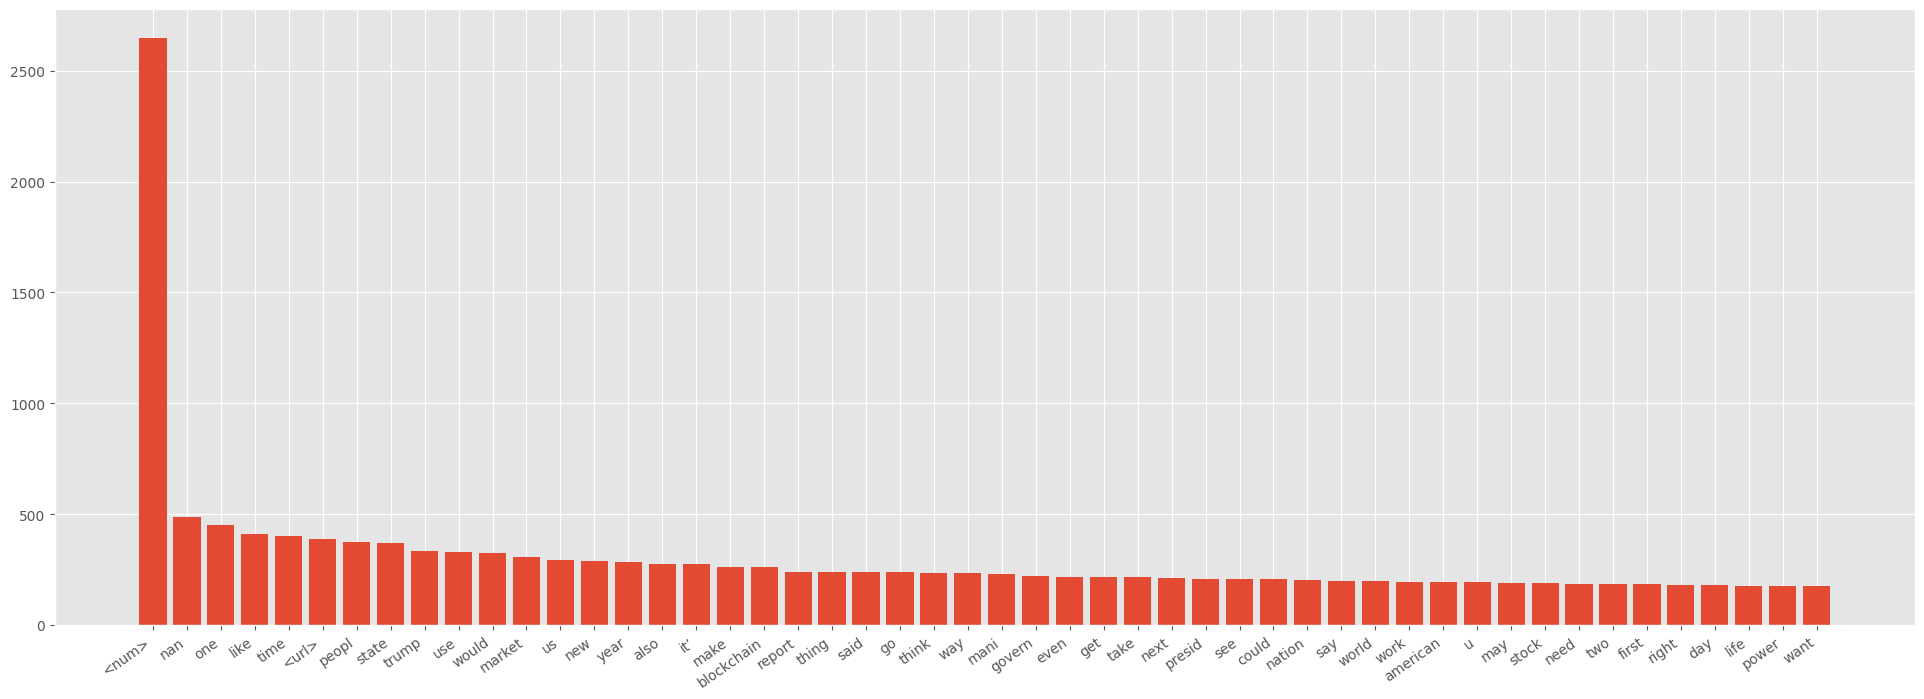

In [9]:
# Make Zipf's law plot of the 50 most common tokens after preprocessing
# Gather all text from NL columns, split into tokens, count
all_text = " ".join(
    df_clean.select(natural_language_cols)
    .fill_null("")
    .unpivot()
    .get_column("value")
    .to_list()
)
from collections import Counter

token_counts = Counter(all_text.split())
most_common = token_counts.most_common(50)
words, counts = zip(*most_common)

plt.figure(figsize=(24, 8))
plt.bar(list(words), list(counts))
plt.xticks(rotation=35, ha="right")
plt.show()

In [10]:
# import os
# import Stemmer  # PyStemmer (~10× faster than NLTK)

# filepath = "./data/995,000_rows.csv"
# outpath = "./data/995,000_rows_preprocessed.csv"
# chunk_size = 50000

# # Preprocess resources (initialized once)
# stop_words = set(stopwords.words("english"))
# stemmer = Stemmer.Stemmer("english")

# def stem_and_filter(x: str) -> str:
#     words = [w for w in x.split() if w not in stop_words]
#     return " ".join(stemmer.stemWords(words))

# # Remove old output file if it exists so we can append fresh
# if os.path.exists(outpath):
#     os.remove(outpath)

# # Use scan_csv (lazy) and process in chunks to keep memory low
# print('Scanning data to lazyframe')
# lf = pl.scan_csv(filepath, encoding='utf8-lossy')
# total_rows = lf.select(pl.len()).collect().item()
# n_chunks = (total_rows + chunk_size - 1) // chunk_size
# print(
#     f'Processing {total_rows} rows in {n_chunks} chunks of {chunk_size}...'
# )

# for i in range(n_chunks):
#     offset = i * chunk_size
#     # Collect only this chunk from the lazy frame
#     chunk = (
#         lf.slice(offset, chunk_size)
#         .drop(["id", "Unnamed: 0", "keywords", "summary"])
#         .collect()
#     )
#     # Fill nulls
#     chunk = chunk.fill_null("nan")
#     chunk = chunk.with_columns(
#         pl.when(pl.col("meta_keywords") == "['']")
#         .then(pl.lit("nan"))
#         .otherwise(pl.col("meta_keywords"))
#         .alias("meta_keywords")
#     )
#     # --- Regex cleaning via native Polars (runs in Rust, not Python) ---
#     chunk = chunk.with_columns(
#         [
#             pl.col(col)
#             .str.to_lowercase()
#             .str.replace_all(email_str, " <EMAIL> ")
#             .str.replace_all(date_str, " <DATE> ")
#             .str.replace_all(url_str, " <URL> ")
#             .str.replace_all(num_str, " <NUM> ")
#             .str.replace_all(special_str, " ")
#             .str.replace_all(apostrephe_str, "")
#             .str.replace_all(ws_str, " ")
#             .str.strip_chars()
#             for col in natural_language_cols
#         ]
#     )
#     # --- Stop-word removal + stemming (PyStemmer is C-based, ~10× faster) ---
#     chunk = chunk.with_columns(
#         [
#             pl.col(col)
#             .map_elements(stem_and_filter, return_dtype=pl.String)
#             .alias(col)
#             for col in natural_language_cols
#         ]
#     )
#     # Write: first chunk with header (creates file), rest append without header
#     if i == 0:
#         chunk.write_csv(outpath)
#     else:
#         with open(outpath, "a") as f:
#             chunk.write_csv(f, include_header=False)
#     sys.stdout.write(f'\r{i+1}/{n_chunks} chunks processed - {offset + len(chunk)} rows so far')
#     sys.stdout.flush()
#     del chunk  # Free memory immediately

# print("\nDone. Preprocessed data saved to", outpath)

In [ ]:
df_clean = pl.read_csv("./data/995,000_rows_preprocessed.csv", n_rows=100_000).to_pandas()
df_raw = pl.read_csv('./data/995,000_rows.csv', ignore_errors=True).to_pandas()

In [3]:
# average article length
print('mean words per article: {:.4f}'.format(df_clean.content.apply(lambda x : len(x.split())).mean()))

mean words per article: 278.9742


In [4]:
# average title length
print('mean words per title: {:.4f}'.format(df_clean.title.apply(lambda x : len(x.split())).mean()))

mean words per title: 6.1368


In [5]:
# average word length in article
print('mean word length in article: {:.4f}'.format(np.mean([len(x) for x in df_clean.content.sum().split()])))

mean word length in article: 5.4671


In [6]:
# average word length in title
print('mean word length in article: {:.4f}'.format(np.mean([len(x) for x in df_clean.title.sum().split()])))

mean word length in article: 6.3863


In [7]:
# average LIX-score per article

# lix formula : https://en.wikipedia.org/wiki/Lix_(readability_test)
def lix_score(doc: str):
    doc = str(doc)
    words = doc.split()

    # calculate number of words
    n_words = len(words)

    # calculate number of sentences # approx number of '. 's
    n_sentences = doc.count('. ') + 1 # +1 for last sentence

    # count 'long' words >= 7 characters
    n_long = np.sum([len(x) >= 7 for x in words])

    # formula
    lix = (n_words/n_sentences) + 100*(n_long/n_words)
    return lix

print('average lix-score per article: {:.4f}'.format(df_raw.content.apply(lix_score).mean()))

average lix-score per article: 73.8966


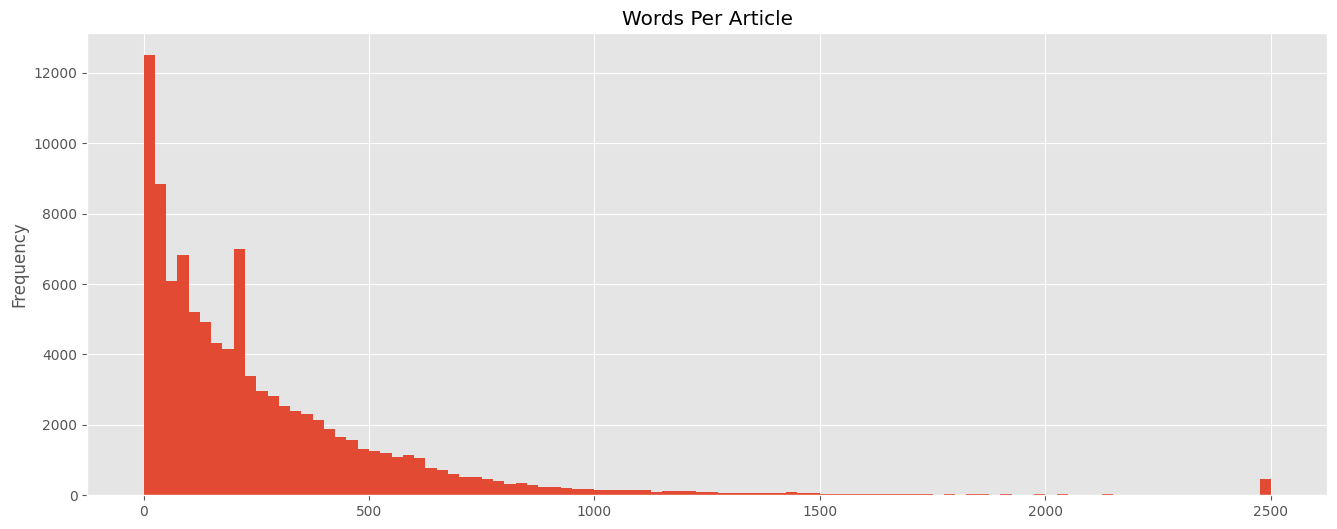

In [59]:
# plot article length
df_clean.content.apply(lambda x : min(2500,len(x.split()))).plot(kind='hist', figsize=(16,6), bins=100)
plt.title('Words Per Article')
plt.show()

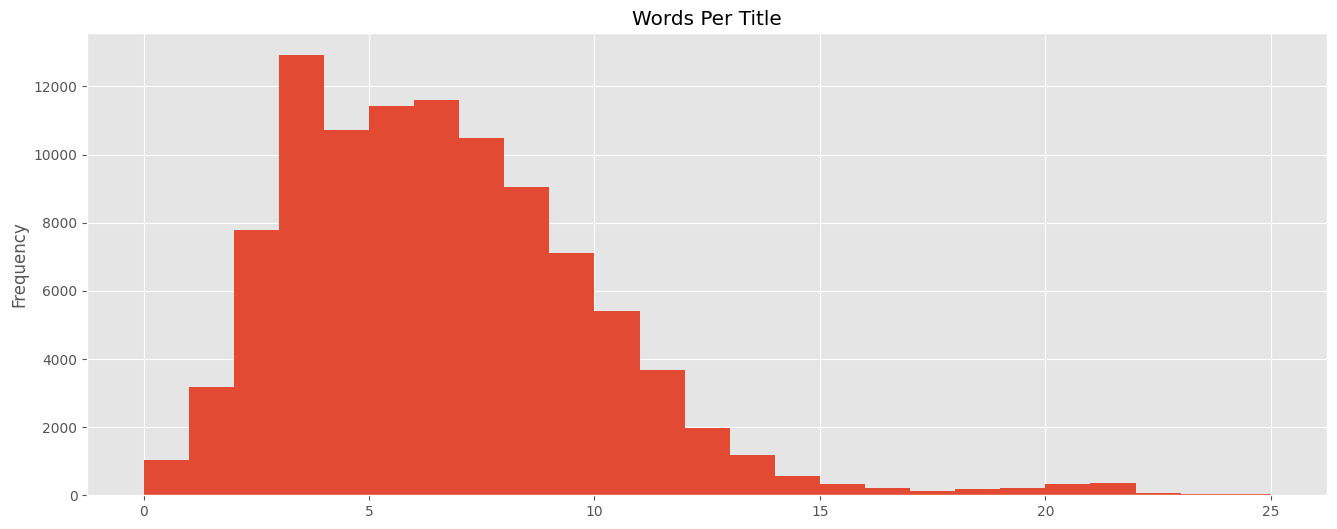

In [58]:
# plot title length
df_clean.title.apply(lambda x : min(25,len(x.split()))).plot(kind='hist', figsize=(16,6), bins=25)
plt.title('Words Per Title')
plt.show()

In [20]:
df_raw.content.apply(lix_score)

0        352.157556
1         66.704545
2         60.615385
3         58.891808
4         93.491142
            ...    
99995     78.222772
99996     72.210526
99997     45.361520
99998     38.768519
99999     81.105505
Name: content, Length: 100000, dtype: float64

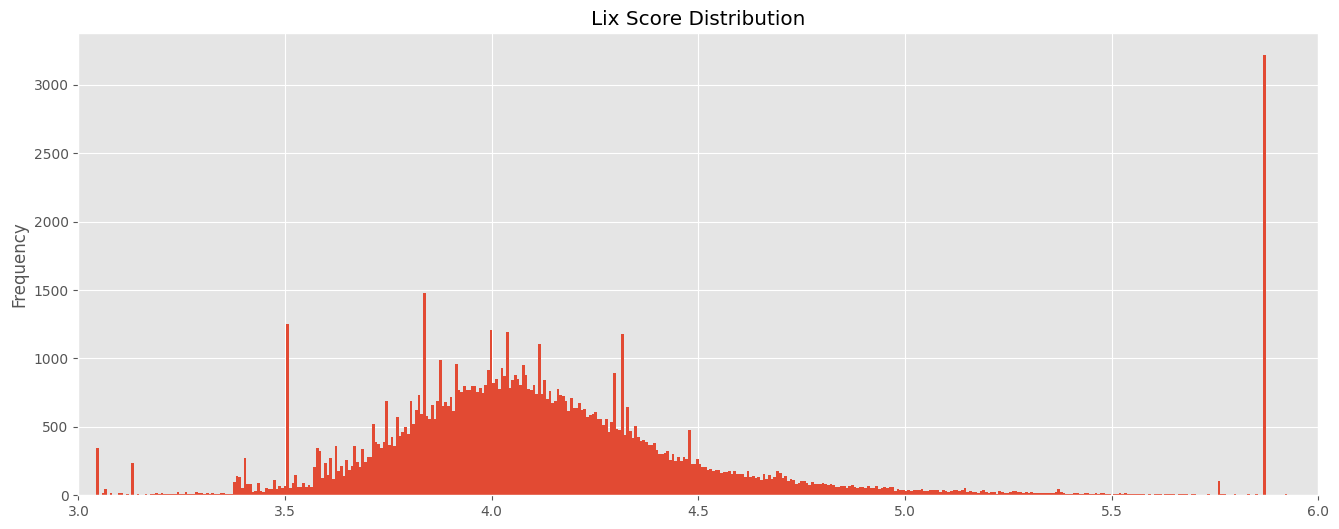

In [57]:
# plot lix-scores
df_raw.content.apply(lambda x : np.log1p(lix_score(x))).plot(kind='hist', figsize=(16,6), bins=1000)
plt.title('Lix Score Distribution')
plt.xlim(3,6) # lix scores from 19 to 400, rest is mostly unseen
plt.show()

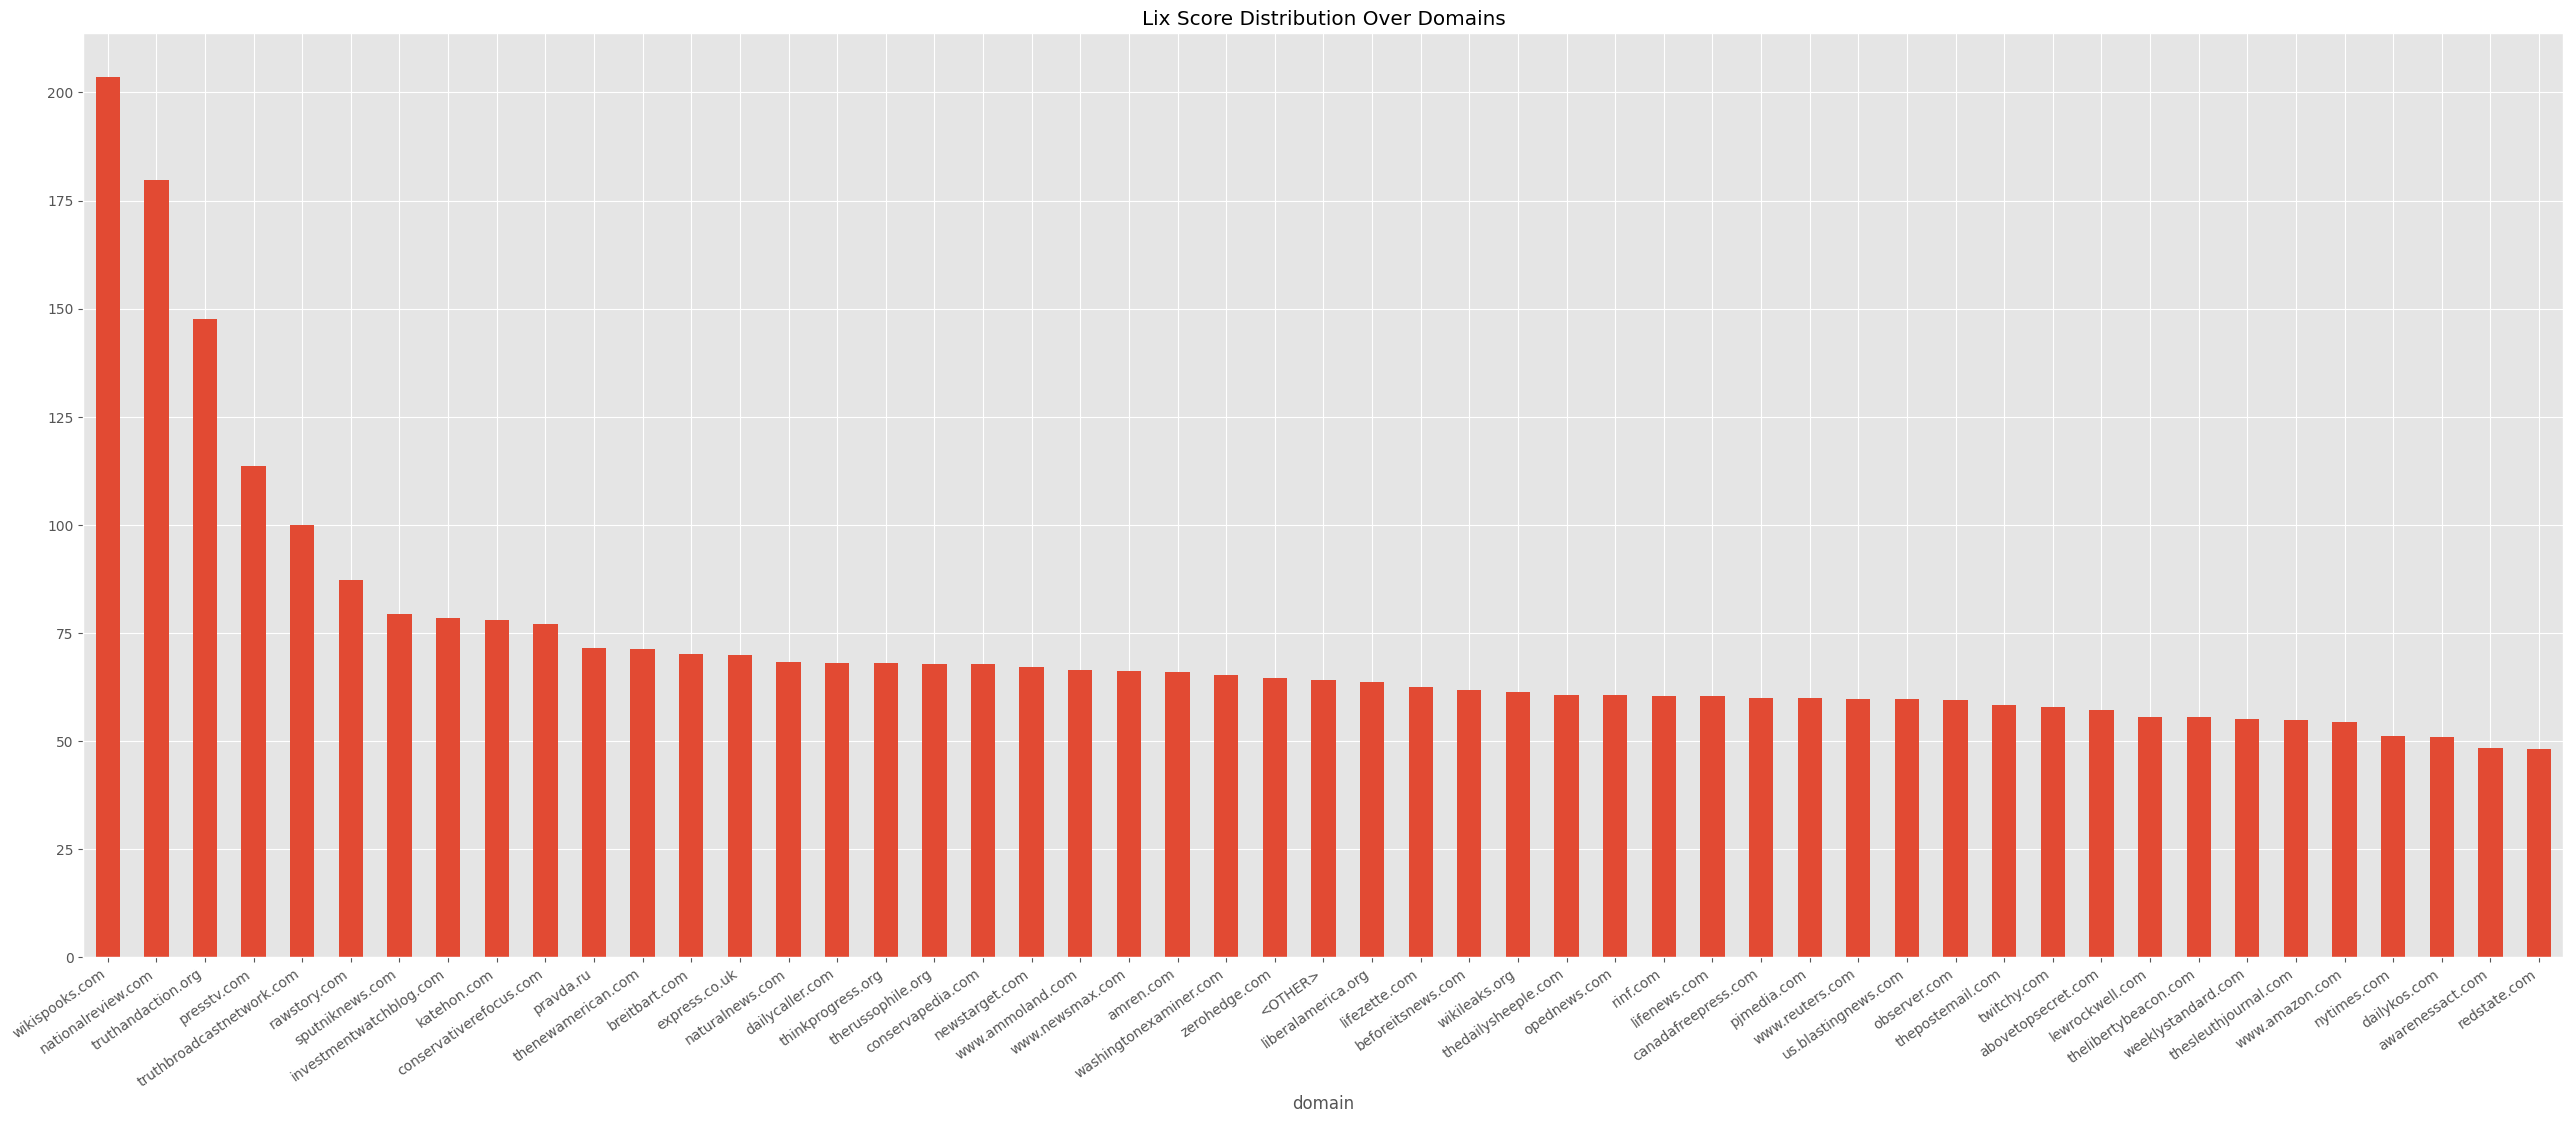

In [18]:
top_domains = df_raw.domain.value_counts().iloc[:50].index
df_raw['domain'] = df_raw['domain'].apply(lambda x : x if x in top_domains else '<OTHER>')

df_raw.iloc[:10_000].groupby('domain').content.sum().apply(lix_score).sort_values(ascending=False).plot(kind='bar', figsize=(32,12))
plt.xticks(rotation=35, ha='right')
plt.title('Lix Score Distribution Over Domains')
plt.show()

### Overview
From this investigation into the LIX-scores of the different articles, we see that it follows a clear log-normal distribution as demonstrated by the QQ-plot above. <br><br>

More interesting, however, is how there is a massive cluster articles containing a LIX-score of 352.157556, which is a clear outlier. To investigate this further, we'll look at some of these outliers and whether they exhibit some inherent pattern which is corrupting them.

In [63]:
df_raw.loc[(df_raw.content.apply(lix_score) > 352)&(df_raw.content.apply(lix_score) < 353), 'content'].head(30) # 3214/100,000 rows

0      Plus one article on Google Plus\n\n(Thanks to ...
10     Plus one article on Google Plus\n\n(Thanks to ...
67     Plus one article on Google Plus\n\n(Thanks to ...
68     Plus one article on Google Plus\n\n(Thanks to ...
94     Plus one article on Google Plus\n\n(Thanks to ...
136    Plus one article on Google Plus\n\n(Thanks to ...
147    Plus one article on Google Plus\n\n(Thanks to ...
160    Plus one article on Google Plus\n\n(Thanks to ...
195    Plus one article on Google Plus\n\n(Thanks to ...
211    Plus one article on Google Plus\n\n(Thanks to ...
237    Plus one article on Google Plus\n\n(Thanks to ...
345    Plus one article on Google Plus\n\n(Thanks to ...
391    Plus one article on Google Plus\n\n(Thanks to ...
440    Plus one article on Google Plus\n\n(Thanks to ...
443    Plus one article on Google Plus\n\n(Thanks to ...
459    Plus one article on Google Plus\n\n(Thanks to ...
485    Plus one article on Google Plus\n\n(Thanks to ...
504    Plus one article on Goog

<br>From this, it becomes clear what has happened. In the original raw dataset, looking at the first 100,000 rows, the authors have scraped the same article many thousand times over. And as a results of this scraping error, **about 3.214% of all rows depict the same article!**

In [12]:
# 1. counting the number of URLs in the content
vocab = {}
for idx,col in enumerate(natural_language_cols):
    sys.stdout.write(f'\rCols: {idx+1}/{len(natural_language_cols)}')
    for cell in df[col]:
        for w in cell.split():
            if w in vocab:
                vocab[w] += 1
            else:
                vocab[w] = 1

vocab = {k:val for k,val in sorted(vocab.items(), key=lambda item: item[1], reverse=True)}
vocab = pd.DataFrame({'token': list(vocab.keys()), 'count': list(vocab.values())}).set_index('token')
vocab = vocab[vocab.reset_index()['token'].apply(lambda x: len(x) <= 30).values].reset_index()
vocab.head(30)

Cols: 5/5

,token,count
0,<NUM>,103091
1,nan,16211
2,said,14994
3,one,12916
4,new,12560
5,time,11098
6,state,10846
7,year,10452
8,peopl,10363
9,would,10208


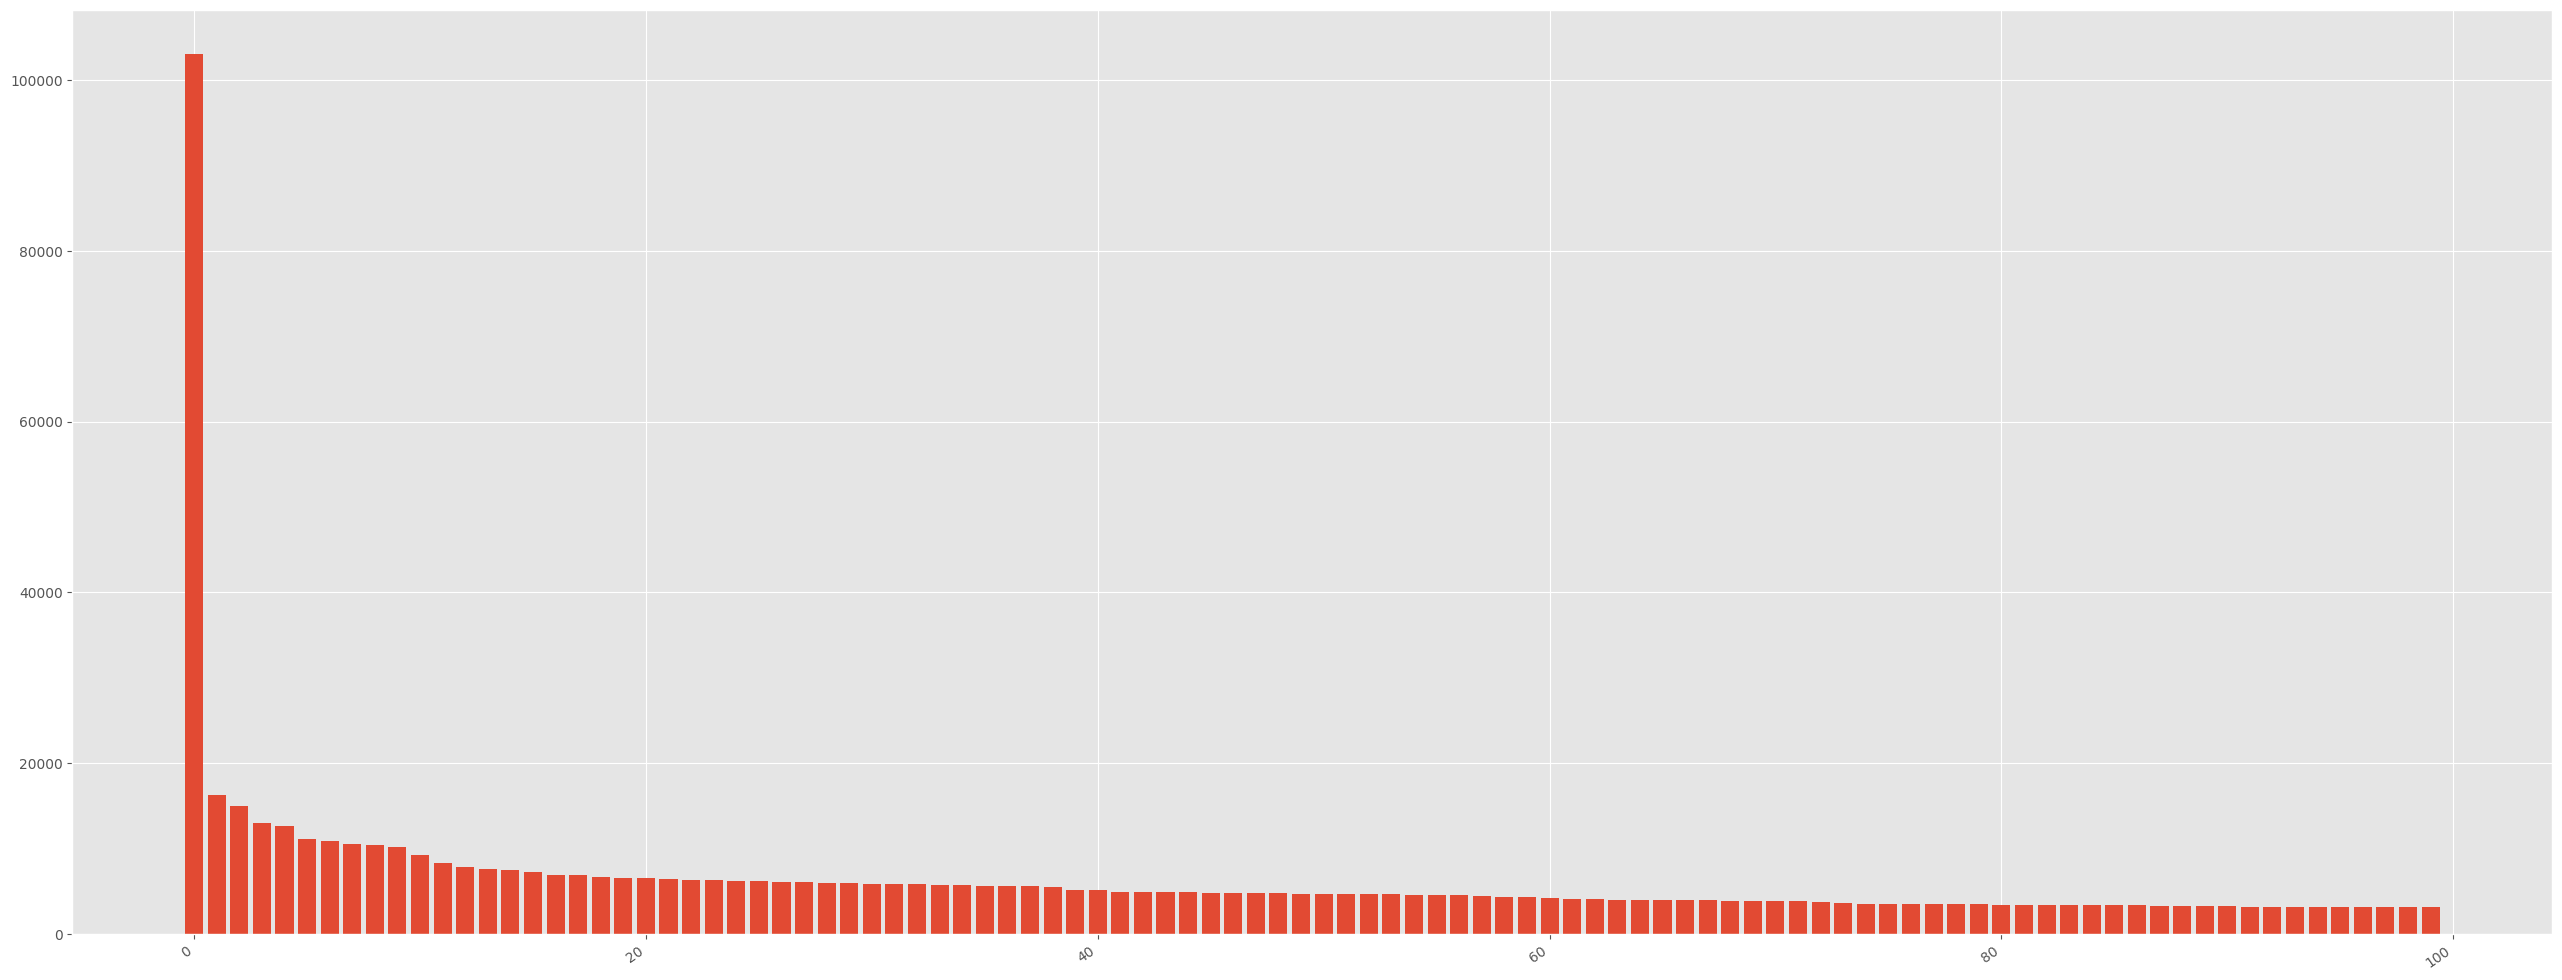

In [13]:
top_vocab = vocab.head(100)
plt.figure(figsize=(32,12))
plt.bar(top_vocab.index, top_vocab['count'])
plt.xticks(rotation=35, ha='right')
plt.show()

In [14]:
vocab.reset_index().query('token == "trump"')

,index,token,count
37,37,trump,5564


<br><h1 style='text-align: center;'>Task 3</h1><br>

In [15]:
special_tokens = ['<URL>','<EMAIL>','<DATE>','<NUM>']
vocab[vocab['token'].apply(lambda x: x in special_tokens).values]

,token,count
0,<NUM>,103091
11,<URL>,8225
771,<DATE>,868
2898,<EMAIL>,170


In [16]:
# size of vocabulary
keep_vocab = vocab[:10000]
keep_vocab

,token,count
0,<NUM>,103091
1,nan,16211
2,said,14994
3,one,12916
4,new,12560
...,...,...
9995,unexplain,21
9996,solitari,21
9997,scotus,21
9998,humanist,21


In [17]:
# Unique labels
print(df['type'].unique())

# We choose to drop the following
drop_rows = ['unknown', 'nan', '2018-02-10 13:43:39.521661']

# Drop all rows of df with label
dropped = df.drop(df.loc[df['type'].isin(drop_rows)].index)

# Split dataframe in feature and label without loss of information 
# (further reduction needed).
y = dropped['type'].to_list()
X = dropped.drop(['type'], axis=1)
# Split into train set (80%), validation set (10%), and test set(10%)
X_train_raw, X_valtest, y_train_raw, y_valtest = train_test_split(
    X, y, test_size=0.2, random_state=1000
)
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(
    X_valtest, y_valtest, test_size=0.5, random_state=1001
)

<ArrowStringArray>
[ 'political',       'fake',     'satire',   'reliable', 'conspiracy',
 'unreliable',       'bias',      'rumor',    'unknown',        'nan',
  'clickbait',       'hate',    'junksci']
Length: 13, dtype: str
